# Домашнее задание: кластеризация и понижение размерности

В этой домашней работе вы будете работать с методами обучения без учителя и на практике разберётесь, как работают алгоритмы кластеризации и понижения размерности.

В ходе задания вы:
- поработаете с несколькими синтетическими датасетами;
- примените и сравните разные алгоритмы кластеризации;
- посмотрите, как масштабирование признаков влияет на результат;
- разберётесь, когда понижение размерности помогает, а когда — нет;
- научитесь интерпретировать качество кластеризации, а не просто получать результат «из коробки».

Важно понимать, что в задачах кластеризации почти никогда нет единственного правильного ответа. Один и тот же метод может работать хорошо на одних данных и плохо на других. Цель этой домашней работы — увидеть это на практике и понять причины таких различий.

Домашнее задание состоит из текстовых блоков, кодовых ячеек и проверок (`assert`).  
Текстовые ответы являются обязательной частью работы и проверяют понимание используемых методов и полученных результатов.


## Блок 1. Данные и первичный анализ

В этой домашней работе мы будем работать с многомерным прикладным датасетом, содержащим изображения рукописных цифр.  
Каждый объект в этом датасете описывается большим числом признаков, а также имеет известную метку класса (цифру), однако в рамках кластеризации мы будем **игнорировать эту разметку** и рассматривать данные как unlabeled.

Наша цель — посмотреть, как «из коробки» работают методы обучения без учителя на реальных данных:
- сначала изучить структуру данных и понять, как они выглядят в пространстве признаков;
- затем попробовать понизить размерность данных, чтобы получить наглядное представление о возможной структуре;
- после этого применить алгоритмы кластеризации и сравнить их результат с истинными метками.

Так как исходная размерность данных достаточно велика, прямую визуализацию выполнить невозможно. Поэтому первым шагом мы воспользуемся методом понижения размерности (PCA), чтобы получить двумерное представление данных и провести первичный визуальный анализ.


### Датасет Digits

В качестве данных мы будем использовать датасет `load_digits` из `sklearn.datasets`.

Он содержит изображения рукописных цифр от 0 до 9.  
Каждый объект — это изображение размером 8×8 пикселей, которое можно представить в виде вектора из 64 числовых признаков.

Прежде чем переходить к понижению размерности и кластеризации, полезно посмотреть, как выглядят типичные представители этого датасета.


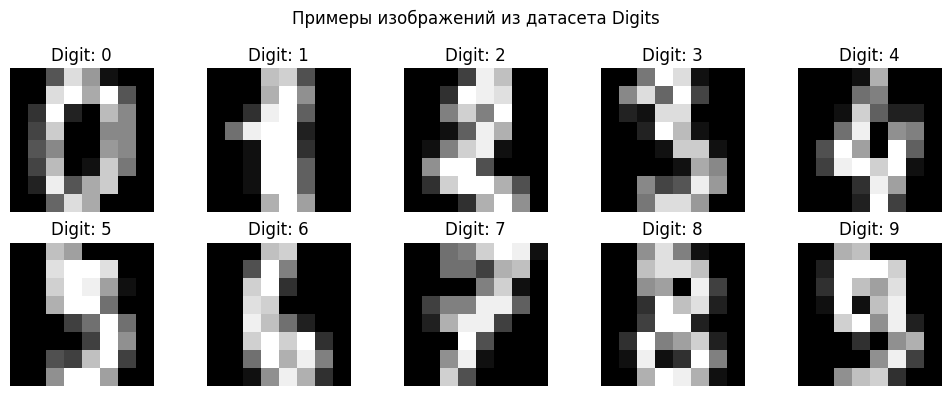

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

digits = load_digits()
X_full = digits.data
y_true = digits.target
images = digits.images


# Посмотрим несколько примеров:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, idx in zip(axes.ravel(), range(10)):
    ax.imshow(images[idx], cmap="gray")
    ax.set_title(f"Digit: {y_true[idx]}")
    ax.axis("off")

plt.suptitle("Примеры изображений из датасета Digits")
plt.tight_layout()
plt.show()

### Как объект выглядит в данных

Каждое изображение в датасете — это картинка 8×8 пикселей.  
Однако для алгоритмов машинного обучения оно хранится не как картинка, а как вектор из 64 чисел.

Посмотрим на один и тот же объект в двух представлениях:
- как изображение;
- как вектор признаков, с которым дальше будут работать алгоритмы.


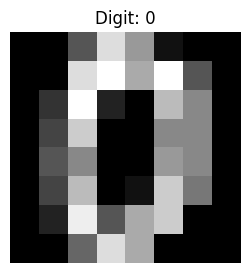

Вектор признаков (64 числа):
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


In [ ]:
# Возьмём один объект
idx = 0

image = images[idx]
vector = X_full[idx]
label = y_true[idx]

# Изображение
plt.figure(figsize=(3, 3))
plt.imshow(image, cmap="gray")
plt.title(f"Digit: {label}")
plt.axis("off")
plt.show()

# Вектор признаков
print("Вектор признаков (64 числа):")
print(vector)


### Работа с данными в формате таблицы

Далее в домашней работе мы будем работать с данными в табличном формате.  
Хотя исходно датасет хранится в виде NumPy-массивов, для дальнейшей работы удобнее использовать `pandas.DataFrame`.

Каждая строка таблицы будет соответствовать одному изображению,  
а каждый столбец — одному пикселю (признаку).


In [ ]:
# Создадим осмысленные имена признаков и переведём данные в pandas.DataFrame
feature_names = [f"pixel_{i}" for i in range(X_full.shape[1])]
df = pd.DataFrame(X_full, columns=feature_names)
df.head()


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_54,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [ ]:
from sklearn.decomposition import PCA

# TODO:
# 1. Создайте объект PCA, который понижает размерность до 2 компонент
# 2. Примените его к DataFrame df
# 3. Сохраните результат в DataFrame df_pca с колонками ["PC1", "PC2"]
# 4. Посчитайте долю объяснённой дисперсии для двух компонент
#    (одно число, сумма explained_variance_ratio_)

# YOUR CODE HERE


In [ ]:
assert isinstance(df_pca, pd.DataFrame)
assert df_pca.shape == (df.shape[0], 2)

assert "PC1" in df_pca.columns
assert "PC2" in df_pca.columns

assert isinstance(explained_variance_2d, float)
assert 0 < explained_variance_2d < 1


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# TODO:
# 1. Для числа компонент от 1 до 64 обучите PCA на датасете df
# 2. Для каждого числа компонент посчитайте суммарную explained_variance_ratio_
# 3. Постройте график зависимости:
#    x — число компонент
#    y — доля объяснённой дисперсии
#
# Результаты сохраните в список explained_variance

# YOUR CODE HERE


In [ ]:
assert isinstance(explained_variance, list)
assert len(explained_variance) == df.shape[1]

assert all(isinstance(v, float) for v in explained_variance)
assert all(0 < v <= 1 for v in explained_variance)

assert all(
    explained_variance[i] <= explained_variance[i + 1]
    for i in range(len(explained_variance) - 1)
)


### Визуализация данных в пространстве двух главных компонент

Далее будем работать с двумерным представлением данных, полученным с помощью PCA.  
Посмотрим, как выглядят объекты в пространстве двух главных компонент и как в нём располагаются цифры.


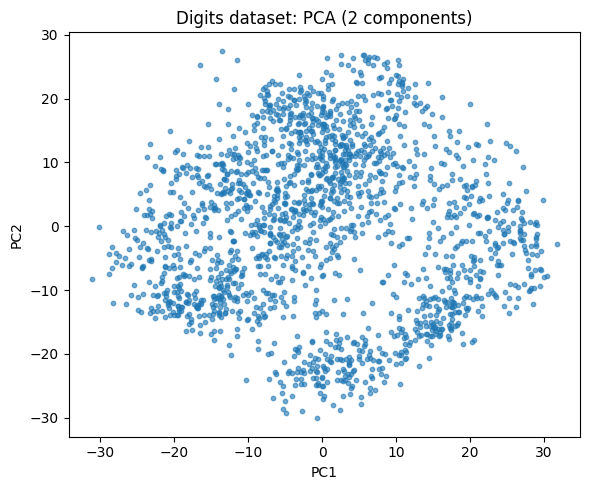

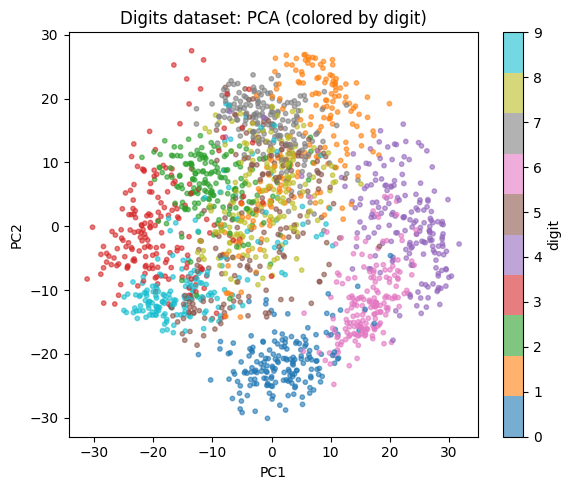

In [ ]:
plt.figure(figsize=(6, 5))

plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    s=10,
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Digits dataset: PCA (2 components)")
plt.tight_layout()
plt.show()


# Та же проекция, но с раскраской по истинным меткам
plt.figure(figsize=(6, 5))

scatter = plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    c=y_true,
    cmap="tab10",
    s=10,
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Digits dataset: PCA (colored by digit)")
plt.colorbar(scatter, ticks=range(10), label="digit")
plt.tight_layout()
plt.show()


По этой визуализации видно, что в пространстве двух главных компонент цифры разделяются не идеально: часть облаков заметно перекрывается. Это ожидаемо. PCA не пытается «разделить классы», он просто сжимает данные так, чтобы сохранить как можно больше общей вариативности.

Перекрытия здесь во многом логичны: некоторые цифры действительно похожи по форме, поэтому их изображения оказываются близко и в признаковом пространстве. Например, часто смешиваются группы вроде **3 и 5**, **4 и 9**, **1 и 7**, **0 и 6/8** — у них есть общие элементы написания, из-за которых модели (и люди) иногда «путаются».

Дальше мы будем работать именно с этой двумерной проекцией и попробуем построить на ней кластеры с помощью **KMeans** и **DBSCAN**. Наша цель — понять, как ведут себя разные алгоритмы кластеризации на реальных данных, где границы между группами не являются идеально чёткими.


## Блок 2. KMeans

В этом блоке мы начинаем работать с алгоритмами кластеризации.

Первым рассмотрим **KMeans** — один из самых простых и популярных алгоритмов кластеризации.  
Наша задача здесь — не найти «идеальное» разбиение, а посмотреть, **как меняется результат при разных гиперпараметрах** и как это отражается на визуализации в двумерном пространстве.

Мы будем:
- применять KMeans к двумерной PCA-проекции данных;
- менять ключевые гиперпараметры алгоритма (в первую очередь число кластеров);
- смотреть, как при этом меняется разбиение точек на экране.

Важно помнить, что в задачах кластеризации результат сильно зависит от выбранных параметров, и один и тот же алгоритм может давать качественно разные ответы при разных настройках.


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# TODO:
# 1. Создайте модель KMeans с числом кластеров k = 10
# 2. Обучите её на данных df_pca
# 3. Получите кластерные метки
# 4. Визуализируйте результат кластеризации в пространстве двух главных компонент
#
# Используйте df_pca["PC1"] и df_pca["PC2"] для построения scatter plot

# YOUR CODE HERE


In [ ]:
assert isinstance(labels_kmeans, np.ndarray)
assert labels_kmeans.shape[0] == df_pca.shape[0]

# Проверяем, что получилось ровно k кластеров
assert len(np.unique(labels_kmeans)) == 10


In [ ]:
from sklearn.metrics import silhouette_score, adjusted_rand_score

# TODO:
# 1. Посчитайте silhouette score для кластеризации KMeans
#    (используйте df_pca и labels_kmeans)
# 2. Посчитайте Adjusted Rand Index (ARI),
#    сравнив labels_kmeans с истинными метками y_true
#
# Сохраните результаты в переменные:
# - silhouette
# - ari_score

# YOUR CODE HERE


In [ ]:
assert isinstance(silhouette, float)
assert -1 <= silhouette <= 1

assert isinstance(ari_score, float)
assert -1 <= ari_score <= 1


In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt

# TODO:
# 1. Для числа компонент от 2 до 30:
#    - понизьте размерность данных df с помощью PCA
#    - обучите KMeans с k = 10
#    - посчитайте silhouette score
#    - посчитайте ARI (используя y_true)
# 2. Постройте два графика:
#    - silhouette score vs number of components
#    - ARI vs number of components
#
# Сохраните результаты в списки:
# - silhouette_scores
# - ari_scores

# YOUR CODE HERE


In [ ]:
assert isinstance(silhouette_scores, list)
assert isinstance(ari_scores, list)

assert len(silhouette_scores) == len(range(2, 64))
assert len(ari_scores) == len(range(2, 64))

assert all(isinstance(s, float) for s in silhouette_scores)
assert all(isinstance(a, float) for a in ari_scores)

assert all(-1 <= s <= 1 for s in silhouette_scores)
assert all(-1 <= a <= 1 for a in ari_scores)


### Вопросы для анализа

Ответьте на следующие вопросы, опираясь на полученные графики silhouette score и ARI:

1. Как ведёт себя silhouette score при увеличении числа главных компонент?
2. Как ведёт себя ARI при увеличении числа главных компонент?
3. Почему silhouette score и ARI меняются по-разному?
4. Можно ли выбрать «лучшее» число главных компонент, исходя только из silhouette score?
5. Какое число главных компонент вы бы выбрали для дальнейшей кластеризации и почему?
6. Какой вывод можно сделать о связи между понижением размерности, визуализацией данных и качеством кластеризации?


### Ваши выводы
1.  
2.  
3.  
4.   
5.  
6.

## Блок 3. DBSCAN

В этом блоке мы попробуем другой подход к кластеризации — **DBSCAN**.

Если KMeans заранее требует указать число кластеров, то DBSCAN работает иначе:
- он ищет **области высокой плотности** и объединяет их в кластеры;
- отдельные точки, которые не относятся ни к одной плотной области, помечаются как **шум**.

Наша цель — посмотреть, как DBSCAN ведёт себя на тех же данных и насколько результат чувствителен к настройкам.

В этом блоке мы будем:
- запускать DBSCAN на PCA-проекциях разной размерности (например, 2, 10, 20 компонент);
- перебирать гиперпараметры DBSCAN (`eps` и `min_samples`);
- смотреть, как меняются:
  - число кластеров и доля «шума»,
  - метрики качества (silhouette score и ARI).

По сути, здесь мы исследуем, как **настройки алгоритма** и **сжатие PCA** вместе влияют на результат кластеризации.



In [ ]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# TODO:
# 1. Создайте модель DBSCAN с некоторыми значениями eps и min_samples
#    (например, eps=1.5, min_samples=5)
# 2. Обучите модель на данных df_pca
# 3. Получите кластерные метки
# 4. Визуализируйте результат кластеризации в пространстве двух главных компонент
#
# Обратите внимание, что DBSCAN может помечать часть точек как шум (метка -1)

# YOUR CODE HERE


In [ ]:
assert isinstance(labels_dbscan, np.ndarray)
assert labels_dbscan.shape[0] == df_pca.shape[0]

assert np.all(np.isin(labels_dbscan, np.unique(labels_dbscan)))


In [ ]:
# TODO:
# 1. Посчитайте ARI для кластеризации DBSCAN,
#    сравнив labels_dbscan с истинными метками y_true
# 2. Посчитайте silhouette score для DBSCAN
#    (учтите, что silhouette имеет смысл считать,
#     только если найдено больше одного кластера и есть нешумовые точки)
#
# Сохраните результаты в переменные:
# - ari_dbscan
# - silhouette_dbscan
#
# Если silhouette score посчитать невозможно, установите silhouette_dbscan = None

# YOUR CODE HERE


In [ ]:
assert isinstance(ari_dbscan, float)
assert -1 <= ari_dbscan <= 1

assert silhouette_dbscan is None or isinstance(silhouette_dbscan, float)


In [ ]:
# TODO:
# 1. Зафиксируйте параметры DBSCAN (eps и min_samples)
# 2. Для числа компонент PCA в диапазоне от 2 до 31:
#    - понизьте размерность данных df
#    - запустите DBSCAN
#    - посчитайте ARI по сравнению с y_true
# 3. Сохраните результаты в словарь вида:
#    pca_components_to_ari = {n_components: ari_value}

# YOUR CODE HERE


In [ ]:
assert isinstance(pca_components_to_ari, dict)
assert set(pca_components_to_ari.keys()) == set(range(2, 32))

for v in pca_components_to_ari.values():
    assert isinstance(v, float)
    assert -1 <= v <= 1


In [ ]:
# TODO:
# Используя словарь pca_components_to_ari:
# 1. Постройте график зависимости ARI от числа главных компонент PCA
# 2. По оси x — число компонент
# 3. По оси y — значение ARI


In [ ]:
assert len(components) == len(ari_values)
assert len(components) > 0

assert all(isinstance(x, int) for x in components)
assert all(isinstance(v, float) for v in ari_values)


In [ ]:
# TODO: Что здесь происходит?

# Мы видим, что при использовании DBSCAN качество кластеризации резко падает при увеличении числа компонент PCA.
# Почему при добавлении PCA-компонент DBSCAN начинает работать всё хуже, хотя для KMeans PCA обычно помогает?

## Блок 4. Подбор гиперпараметров для KMeans и DBSCAN

В этом блоке мы попробуем формально подобрать гиперпараметры для алгоритмов кластеризации, используя перебор по сетке (grid search).

Мы будем работать **в пространстве двух главных компонент**, чтобы:
- сравнение было честным,
- визуализация оставалась возможной.

Для каждого алгоритма:
- переберём набор гиперпараметров;
- оценим качество кластеризации с помощью метрик;
- попробуем интерпретировать полученные результаты.


In [ ]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score

# TODO:
# 1. Для KMeans переберите значения k из диапазона 2..15
#    Для каждого k:
#      - обучите KMeans на df_pca
#      - посчитайте silhouette score
#      - посчитайте ARI
#
# 2. Для DBSCAN переберите:
#    - eps из списка [0.5, 1.0, 1.5, 2.0]
#    - min_samples из списка [3, 5, 10]
#    Для каждой пары параметров:
#      - обучите DBSCAN на df_pca
#      - посчитайте ARI
#      - silhouette считайте только если это возможно
#
# 3. Сохраните результаты в удобном для анализа виде
#    (например, список словарей или DataFrame)

# YOUR CODE HERE


In [ ]:
assert isinstance(results_df, pd.DataFrame)
assert {"model", "silhouette", "ari"}.issubset(results_df.columns)

assert results_df.shape[0] > 0
assert results_df["ari"].between(-1, 1).all()


### TODO: Анализ результатов grid search

Изучите таблицу с результатами перебора гиперпараметров для KMeans и DBSCAN.

Какие выводы можно сделать по этой таблице?

В частности, попробуйте ответить на следующие вопросы:
- Какие значения гиперпараметров дают наилучшие результаты для KMeans?
- Удалось ли подобрать параметры DBSCAN, которые дают качество, сопоставимое с KMeans?
- Как ведут себя silhouette score и ARI для разных алгоритмов?
- Что эта таблица говорит о применимости KMeans и DBSCAN к данному датасету и выбранному представлению данных?

Ответ оформите в виде короткого текстового вывода


### Ответ:



# Итоговые выводы

В этой работе мы сравнили поведение алгоритмов кластеризации **KMeans** и **DBSCAN** на одном и том же датасете с использованием PCA.  


Мы увидели, что:
- **PCA** существенно влияет на геометрию данных и, как следствие, на качество кластеризации;
- **KMeans** оказывается относительно устойчивым к PCA-сжатию и позволяет извлечь часть структуры данных даже в двумерной проекции;
- **DBSCAN** сильно чувствителен к плотностной структуре и после PCA начинает работать заметно хуже, независимо от подбора гиперпараметров;
- высокое значение silhouette score не гарантирует семантически осмысленные кластеры, что хорошо видно на примере DBSCAN.

Главный вывод работы - **алгоритмы кластеризации нельзя применять механически**.  
Выбор метода, метрик и способа понижения размерности должен учитывать свойства данных и внутреннюю логику алгоритма, а не только формальные показатели качества.
